# Twitter Sentiment / Hate Speech Classification

## Project Overview
This notebook performs text classification on the `tweet.csv` dataset. The target variable is `label`, where:

- `0` = Non-hate / non-offensive tweet
- `1` = Hate / offensive tweet

Objective: 

- Cleans the text
- Vectorizes tweets using TF-IDF
- Train multiple machine learning models
- Evaluates using metrics suitable for imbalanced classification.


In [1]:
# Import required libraries
import os
import re
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_fscore_support
)

RANDOM_STATE = 42


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ta3fvmj8 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


In [ ]:
# Load the dataset
# The first path works when running locally/GitHub/Colab if the CSV is in the same folder.
# The second path was used for executing this notebook in the current environment.
DATA_PATH = "tweet.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "/mnt/data/tweet.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Dataset shape: (31962, 3)
Columns: ['id', 'label', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
# Basic dataset checks
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["label"].value_counts())

print("\nTarget distribution (%):")
print((df["label"].value_counts(normalize=True) * 100).round(2))


Missing values:
id       0
label    0
tweet    0
dtype: int64

Duplicate rows: 0

Target distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Target distribution (%):
label
0    92.99
1     7.01
Name: proportion, dtype: float64


## Data Understanding

The dataset is highly imbalanced. Most tweets belong to class `0`, while a much smaller portion belongs to class `1`. Because of this imbalance, accuracy alone is not enough. We also need to check precision, recall, F1-score, and ROC-AUC, especially for class `1`.


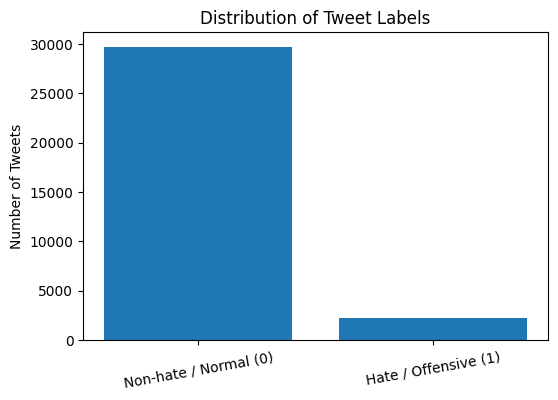

In [4]:
# Plot target distribution
target_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Non-hate / Normal (0)", "Hate / Offensive (1)"], target_counts.values)
plt.title("Distribution of Tweet Labels")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=10)
plt.show()


In [5]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"@user", " ", text)              # remove anonymized user mentions
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"[^a-z#\s]", " ", text)         # keep alphabets and hashtags
    text = re.sub(r"\s+", " ", text).strip()       # remove extra spaces
    return text

df["clean_tweet"] = df["tweet"].apply(clean_text)

df[["tweet", "clean_tweet", "label"]].head()


,tweet,clean_tweet,label
0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so selfi...,0
1,@user @user thanks for #lyft credit i can't us...,thanks for #lyft credit i can t use cause they...,0
2,bihday your majesty,bihday your majesty,0
3,#model i love u take with u all the time in ...,#model i love u take with u all the time in ur,0
4,factsguide: society now #motivation,factsguide society now #motivation,0


In [6]:
# Split features and target
X = df["clean_tweet"]
y = df["label"].astype(int)

# Stratified split preserves class distribution in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))


Training records: 25569
Testing records: 6393

Training target distribution:
label
0    0.9298
1    0.0702
Name: proportion, dtype: float64

Testing target distribution:
label
0    0.9299
1    0.0701
Name: proportion, dtype: float64


## Model Building

The following models are trained and compared:

1. **Multinomial Naive Bayes** — commonly used for text classification.
2. **Logistic Regression** — strong and interpretable baseline for text classification.
3. **Random Forest** — non-linear model used for comparison.

TF-IDF vectorization is used to convert cleaned text into numerical features.


In [7]:
# Define models using pipelines
models = {
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2), min_df=2)),
        ("model", MultinomialNB())
    ]),

    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2), min_df=2)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english", max_features=3000, ngram_range=(1, 1), min_df=2)),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=25,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

results = []
predictions = {}
probabilities = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    if hasattr(model.named_steps["model"], "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        probabilities[model_name] = y_proba
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        roc_auc = np.nan

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[1], average="binary", zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "ROC_AUC": roc_auc,
        "Class_1_Precision": precision,
        "Class_1_Recall": recall,
        "Class_1_F1": f1
    })

results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
results_df


Training Naive Bayes...


Training Logistic Regression...


Training Random Forest...


,Model,Accuracy,ROC_AUC,Class_1_Precision,Class_1_Recall,Class_1_F1
1,Logistic Regression,0.918192,0.941084,0.451861,0.785714,0.573757
0,Naive Bayes,0.954012,0.937204,0.932584,0.370536,0.530351
2,Random Forest,0.934303,0.904249,0.526923,0.611607,0.566116


In [8]:
# Detailed classification reports
for model_name, y_pred in predictions.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-hate / Normal", "Hate / Offensive"],
        zero_division=0
    ))


Naive Bayes
                   precision    recall  f1-score   support

Non-hate / Normal       0.95      1.00      0.98      5945
 Hate / Offensive       0.93      0.37      0.53       448

         accuracy                           0.95      6393
        macro avg       0.94      0.68      0.75      6393
     weighted avg       0.95      0.95      0.94      6393

Logistic Regression
                   precision    recall  f1-score   support

Non-hate / Normal       0.98      0.93      0.95      5945
 Hate / Offensive       0.45      0.79      0.57       448

         accuracy                           0.92      6393
        macro avg       0.72      0.86      0.76      6393
     weighted avg       0.95      0.92      0.93      6393

Random Forest
                   precision    recall  f1-score   support

Non-hate / Normal       0.97      0.96      0.96      5945
 Hate / Offensive       0.53      0.61      0.57       448

         accuracy                           0.93      6393
  

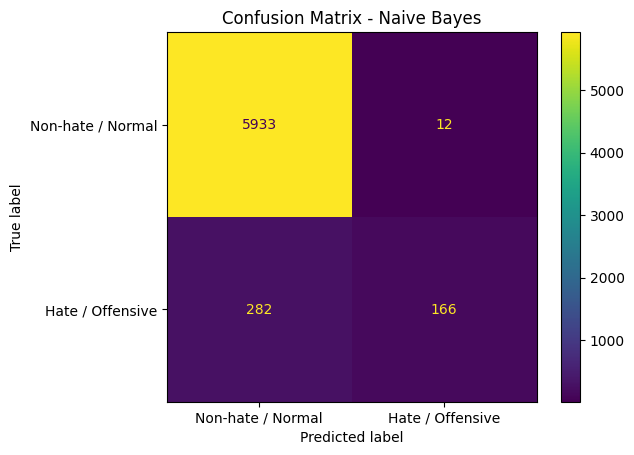

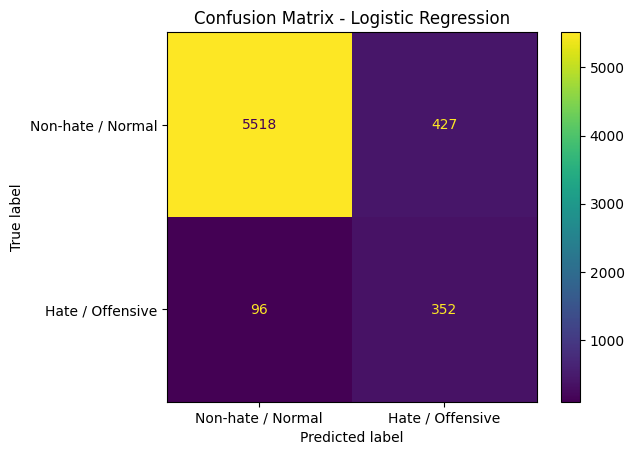

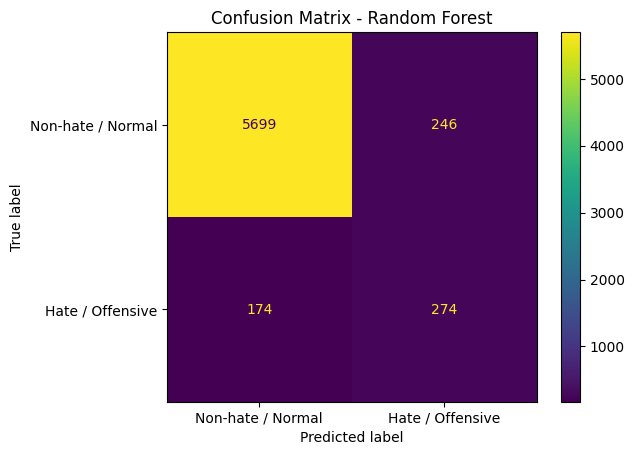

In [9]:
# Confusion matrices
for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-hate / Normal", "Hate / Offensive"]
    )
    disp.plot(values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


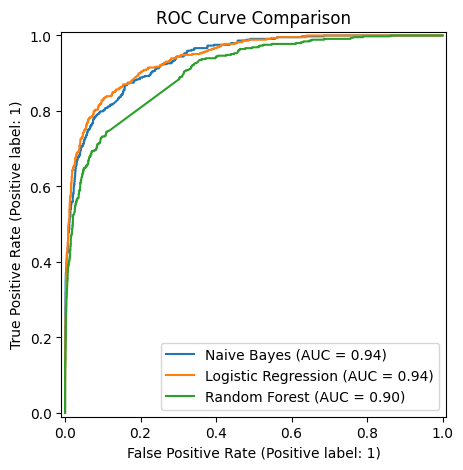

In [10]:
# ROC curves
plt.figure(figsize=(7, 5))

for model_name, model in models.items():
    if model_name in probabilities:
        RocCurveDisplay.from_predictions(
            y_test,
            probabilities[model_name],
            name=model_name,
            ax=plt.gca()
        )

plt.title("ROC Curve Comparison")
plt.show()


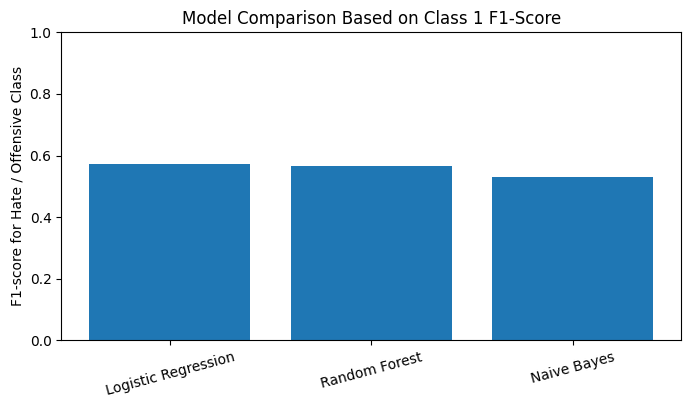

,Model,Accuracy,ROC_AUC,Class_1_Precision,Class_1_Recall,Class_1_F1
1,Logistic Regression,0.918192,0.941084,0.451861,0.785714,0.573757
0,Naive Bayes,0.954012,0.937204,0.932584,0.370536,0.530351
2,Random Forest,0.934303,0.904249,0.526923,0.611607,0.566116


In [11]:
# Model comparison chart
plot_df = results_df.sort_values("Class_1_F1", ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(plot_df["Model"], plot_df["Class_1_F1"])
plt.title("Model Comparison Based on Class 1 F1-Score")
plt.ylabel("F1-score for Hate / Offensive Class")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

results_df


In [ ]:
# Save model comparison result
output_path = "/mnt/data/twitter_sentiment_model_comparison.csv"
results_df.to_csv(output_path, index=False)
print("Saved model comparison to:", output_path)


Saved model comparison to: /mnt/data/twitter_sentiment_model_comparison.csv


## Observations

- The target class is highly imbalanced. Class `0` has the majority of tweets, while class `1` has a much smaller number of tweets.
- Naive Bayes gives high accuracy, but it misses many class `1` tweets because its recall for the minority class is low.
- Logistic Regression with `class_weight="balanced"` improves recall for class `1`, which is important when the goal is to identify hate/offensive tweets.
- Random Forest gives reasonable performance, but text classification generally performs better with linear models such as Logistic Regression when using TF-IDF features.
- For this problem, accuracy alone is not enough. The F1-score and recall for class `1` are more useful because the minority class is the important class to detect.

## Conclusion

This notebook successfully performs Twitter sentiment / hate speech classification using the provided dataset. The data was cleaned, transformed using TF-IDF, and evaluated using multiple classification models.

The best model should be selected based on the project objective. If the objective is overall accuracy, Naive Bayes performs well. However, if the objective is to identify more hate/offensive tweets, Logistic Regression with balanced class weights is more suitable because it improves minority-class recall.

This project demonstrates a complete text classification workflow including data cleaning, feature extraction, model training, model evaluation, and interpretation of results.